<a href="https://colab.research.google.com/github/banteamlak1888/Programming-and-Algorithms-Course/blob/main/gradient_dscent_with_LR_and_log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing gradient descent for  linear and logistic  regression in Python

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
# Sigmoid function for logistic regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# Generic gradient descent function (cost-specific logic handled separately)
def gradient_descent(X, y, model='linear', lr=0.01, epochs=1000):
    m, n = X.shape
    X = np.hstack([np.ones((m, 1)), X])  # Add bias term
    theta = np.zeros((n + 1, 1))
    history = []

    for _ in range(epochs):
        z = X @ theta

        if model == 'linear':
            h = z
            error = h - y
            cost = (1 / (2 * m)) * np.sum(error ** 2)

        elif model == 'logistic':
            h = sigmoid(z)
            error = h - y
            cost = -(1 / m) * np.sum(y * np.log(h + 1e-9) + (1 - y) * np.log(1 - h + 1e-9))

        gradients = (1 / m) * X.T @ error
        theta -= lr * gradients
        history.append(cost)

    return theta, history

In [ ]:
# Predict functions
def predict_linear(X, theta):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    return X @ theta

def predict_logistic(X, theta, threshold=0.5):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    probs = sigmoid(X @ theta)
    return (probs >= threshold).astype(int)


**Linear Regression using Gradient Descent:**
Linear regression aims to fit a linear model to the data by minimizing the mean squared error and R_squared.

In [ ]:
# Dataset for Linear Regression
# Load and scale data
X_lin, y_lin = make_regression(n_samples=100, n_features=1, noise=15)
X_lin = StandardScaler().fit_transform(X_lin)
y_lin = y_lin.reshape(-1, 1)

In [ ]:
# Train model
theta_lin, cost_hist_lin = gradient_descent(X_lin, y_lin, model='linear', lr=0.01, epochs=1000)

In [ ]:
# Predict and evaluate
y_pred_lin = predict_linear(X_lin, theta_lin)
print("Linear Regression Evaluation")
print("  MSE:", mean_squared_error(y_lin, y_pred_lin))
print("  R2 Score:", r2_score(y_lin, y_pred_lin))


Linear Regression Evaluation
  MSE: 239.56746351881043
  R2 Score: 0.45407678108618665


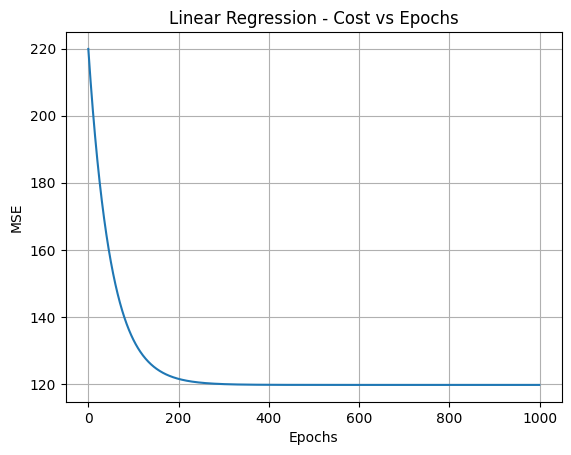

In [ ]:
# Plot cost history
plt.plot(cost_hist_lin)
plt.title("Linear Regression - Cost vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

**Logistic Regression using Gradient Descent**:The performance of the logistic regression model was evaluated using accuracy and the confusion matrix, which provides deeper insight into the model's classification behavior.

In [ ]:
 # Load and scale data
X_log, y_log = make_classification(n_samples=100, n_features=2, n_informative=2,
                                   n_redundant=0, n_classes=2, random_state=42)
X_log = StandardScaler().fit_transform(X_log)
y_log = y_log.reshape(-1, 1)


In [ ]:
# Train model
theta_log, cost_hist_log = gradient_descent(X_log, y_log, model='logistic', lr=0.1, epochs=1000)

In [ ]:
# Predict and evaluate
y_pred_log = predict_logistic(X_log, theta_log)
print("\nLogistic Regression Evaluation")
print("  Accuracy:", accuracy_score(y_log, y_pred_log))
print("  Confusion Matrix:\n", confusion_matrix(y_log, y_pred_log))



Logistic Regression Evaluation
  Accuracy: 0.99
  Confusion Matrix:
 [[50  0]
 [ 1 49]]


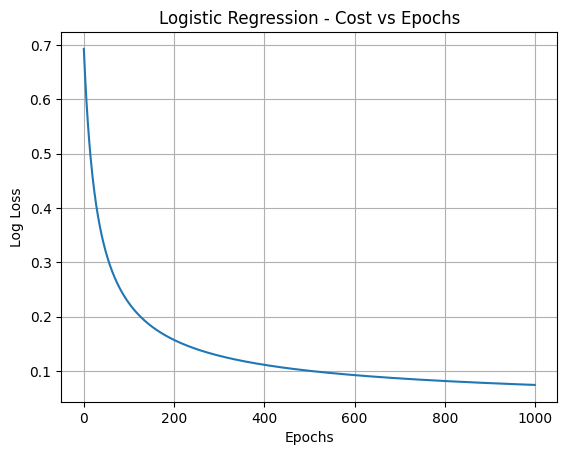

In [ ]:
# Plot cost history
plt.plot(cost_hist_log)
plt.title("Logistic Regression - Cost vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.grid(True)
plt.show()
